<a href="https://colab.research.google.com/github/Mounikab05-hub/HHS_Unaccompanied_Alien_Children_Program/blob/main/HHS_Unaccompanied_Alien_Children_Program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/HHS_Unaccompanied_Alien_Children_Program.csv')
print(df.head())

                Date  Children apprehended and placed in CBP custody*  \
0  December 21, 2025                                              6.0   
1  December 18, 2025                                             11.0   
2  December 17, 2025                                              7.0   
3  December 16, 2025                                              8.0   
4  December 15, 2025                                             11.0   

   Children in CBP custody  Children transferred out of CBP custody  \
0                     18.0                                     11.0   
1                     50.0                                      6.0   
2                     31.0                                     11.0   
3                     54.0                                     15.0   
4                     42.0                                      9.0   

  Children in HHS Care  Children discharged from HHS Care  
0                2,484                               14.0  
1             

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
print(df.isnull().sum())

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


In [ ]:
df = df.rename(columns={
    'Children apprehended and placed in CBP custody*': 'CBP_Apprehended',
    'Children in CBP custody': 'CBP_Custody',
    'Children transferred out of CBP custody': 'Transferred_Out',
    'Children in HHS Care': 'HHS_Care',
    'Children discharged from HHS Care': 'HHS_Discharged'
})

In [ ]:
print(df.columns)

Index(['Date', 'CBP_Apprehended', 'CBP_Custody', 'Transferred_Out', 'HHS_Care',
       'HHS_Discharged'],
      dtype='object')


In [ ]:
print(df.describe())

                                Date  CBP_Apprehended  CBP_Custody  \
count                            720       720.000000   720.000000   
mean   2024-07-06 05:29:59.999999744        93.523611   171.494444   
min              2023-01-12 00:00:00         0.000000     7.000000   
25%              2023-10-16 18:00:00        12.000000    36.000000   
50%              2024-07-05 12:00:00        99.000000   193.000000   
75%              2025-03-25 06:00:00       147.250000   263.250000   
max              2025-12-21 00:00:00       333.000000   531.000000   
std                              NaN        72.646625   126.354965   

       Transferred_Out  HHS_Discharged  
count       720.000000      720.000000  
mean        128.668056      173.406944  
min           0.000000        0.000000  
25%          14.000000       19.750000  
50%         157.000000      181.000000  
75%         199.250000      267.000000  
max         440.000000      505.000000  
std          97.322012      125.702841  


In [ ]:
df['Transfer_Efficiency'] = (
    df['Transferred_Out'] / df['CBP_Apprehended']
) * 100

print(df[['Date', 'Transfer_Efficiency']])

           Date  Transfer_Efficiency
0    2025-12-21           183.333333
1    2025-12-18            54.545455
2    2025-12-17           157.142857
3    2025-12-16           187.500000
4    2025-12-15            81.818182
...         ...                  ...
1165        NaT                  NaN
1166        NaT                  NaN
1167        NaT                  NaN
1168        NaT                  NaN
1169        NaT                  NaN

[1170 rows x 2 columns]


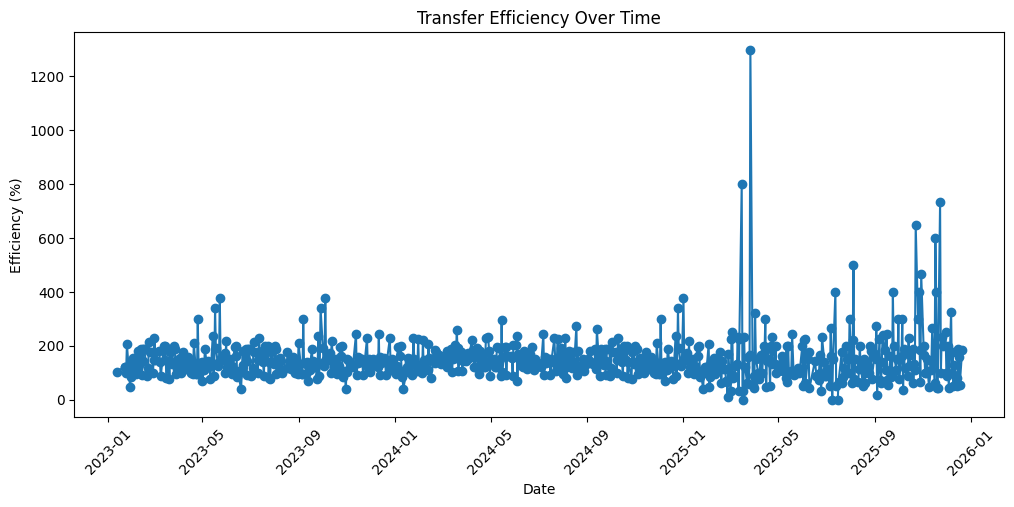

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Transfer_Efficiency'],
    marker='o'
)

plt.title('Transfer Efficiency Over Time')
plt.xlabel('Date')
plt.ylabel('Efficiency (%)')

plt.xticks(rotation=45)

plt.show()

In [ ]:
numeric_columns = [
    'CBP_Apprehended',
    'CBP_Custody',
    'Transferred_Out',
    'HHS_Care',
    'HHS_Discharged'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
print(df.dtypes)

Date                   datetime64[ns]
CBP_Apprehended               float64
CBP_Custody                   float64
Transferred_Out               float64
HHS_Care                      float64
HHS_Discharged                float64
Transfer_Efficiency           float64
dtype: object


In [ ]:
df['Backlog'] = (
    df['CBP_Custody'] +
    df['HHS_Care']
)

print(df[['Date', 'Backlog']])

           Date  Backlog
0    2025-12-21      NaN
1    2025-12-18      NaN
2    2025-12-17      NaN
3    2025-12-16      NaN
4    2025-12-15      NaN
...         ...      ...
1165        NaT      NaN
1166        NaT      NaN
1167        NaT      NaN
1168        NaT      NaN
1169        NaT      NaN

[1170 rows x 2 columns]


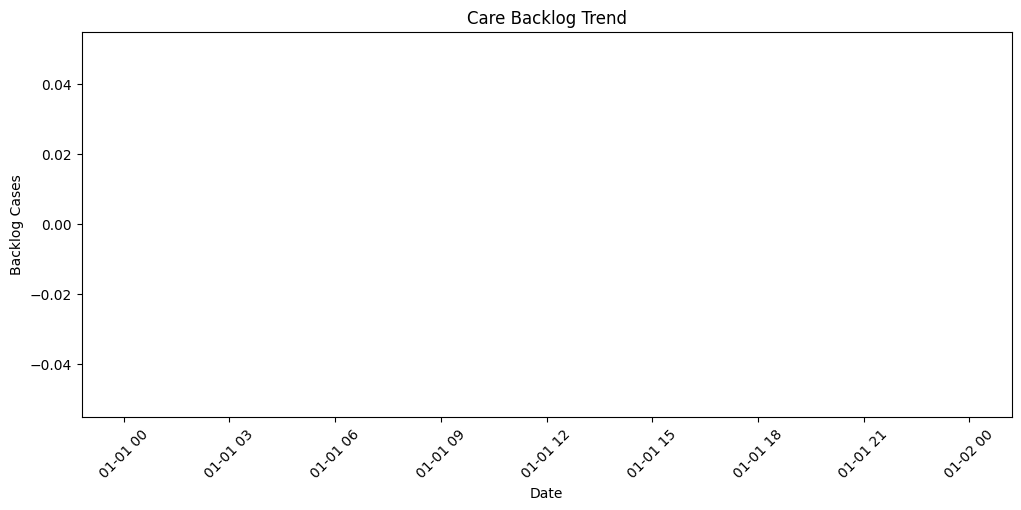

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Backlog'],
    marker='o'
)

plt.title('Care Backlog Trend')
plt.xlabel('Date')
plt.ylabel('Backlog Cases')

plt.xticks(rotation=45)

plt.show()

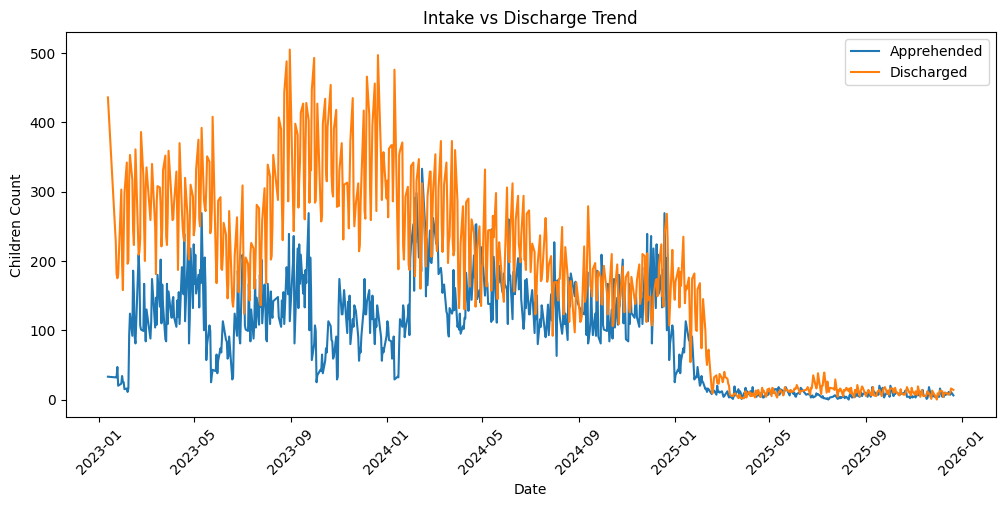

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['CBP_Apprehended'],
    label='Apprehended'
)

plt.plot(
    df['Date'],
    df['HHS_Discharged'],
    label='Discharged'
)

plt.legend()

plt.title('Intake vs Discharge Trend')
plt.xlabel('Date')
plt.ylabel('Children Count')

plt.xticks(rotation=45)

plt.show()

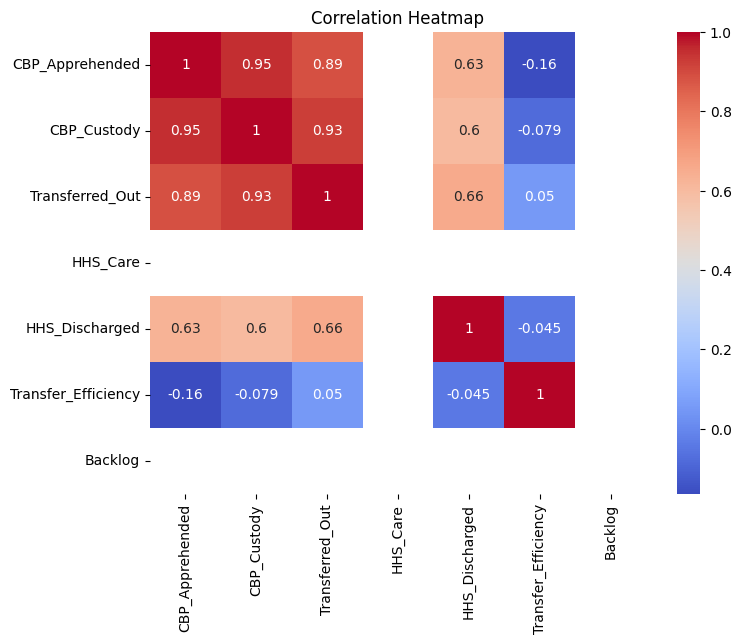

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop(columns=['Date']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

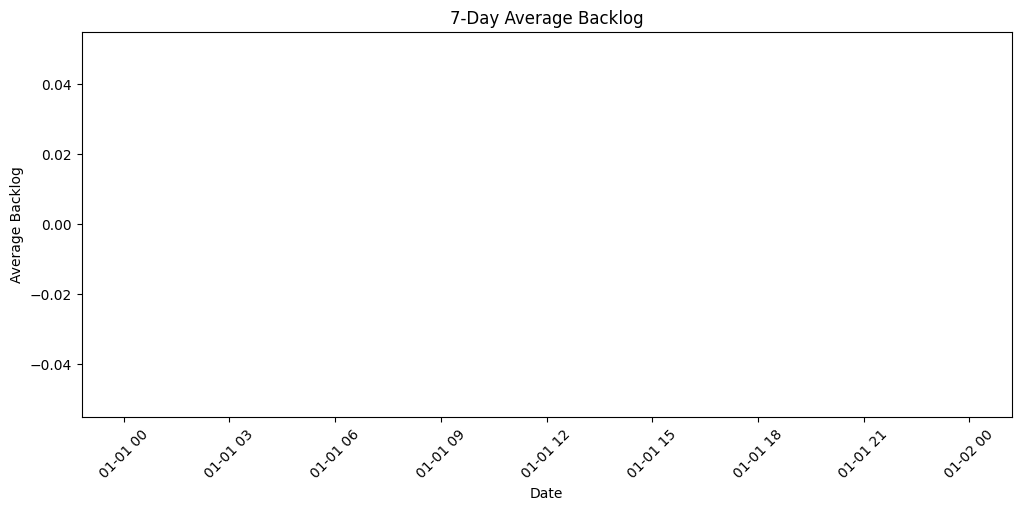

In [ ]:
df['7Day_Avg_Backlog'] = (
    df['Backlog'].rolling(window=7).mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['7Day_Avg_Backlog']
)

plt.title('7-Day Average Backlog')

plt.xlabel('Date')
plt.ylabel('Average Backlog')

plt.xticks(rotation=45)

plt.show()

In [ ]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_summary = df.groupby('Month')[[
    'CBP_Apprehended',
    'CBP_Custody',
    'Transferred_Out',
    'HHS_Care',
    'HHS_Discharged'
]].sum()

print("\nMonthly Summary")
print(monthly_summary)